In [2]:
library(readxl)
library(writexl)
library(dplyr)
library(ggplot2)
library(ggExtra)
library(anthroplus)
library(scales)

In [3]:
male_data <- read_excel("male_data.xlsx")
male_data

# A tibble: 827 × 8
   ks    tl                   umur sex      tb    bb    bf   bmi
   <chr> <dttm>              <dbl> <chr> <dbl> <dbl> <dbl> <dbl>
 1 SM71  2013-06-24 00:00:00  12.3 M      143   39.5  13.4  19.3
 2 SM72  2012-10-01 00:00:00  13   M      148.  37.5  11.1  17.2
 3 SM73  2012-12-22 00:00:00  12.8 M      158   41.8   8.1  16.7
 4 SM74  2013-02-14 00:00:00  12.6 M      160   64.7  22    25.3
 5 SM75  2013-04-30 00:00:00  12.4 M      145   45.3   0    21.5
 6 SM76  2012-10-28 00:00:00  12.9 M      166.  69.5  27.8  25.1
 7 SM77  2012-10-10 00:00:00  12.9 M      148   42.3  11.4  19.3
 8 SM78  2013-03-27 00:00:00  12.5 M      156.  44.4  12.2  18.4
 9 SM79  2013-02-02 00:00:00  12.7 M      148.  51.2  23.4  23.5
10 SM710 2012-05-20 00:00:00  13.3 M      160.  47.5  11.1  18.7
# ℹ 817 more rows
# ℹ Use `print(n = ...)` to see more rows

In [8]:
# menyiapkan data
male_data_clean <- male_data %>%
  filter(!is.na(bb) & !is.na(tb) & !is.na(umur)) %>%
  mutate(
    bb = as.numeric(bb),
    tb = as.numeric(tb),
    # mengubah satuan umur dari tahun ke bulan
    umur_bulan = as.numeric(umur) * 12 
  )

# 2. Run the WHO calculator as a standalone mathematical matrix
who_calculations <- anthroplus_zscores(
  sex = rep(1, nrow(male_data_clean)), 
  age_in_months = male_data_clean$umur_bulan,
  height_in_cm = male_data_clean$tb,
  weight_in_kg = male_data_clean$bb
)

# 3. Bind the true 'zbfa' column and execute the clinical thresholds
male_data_final <- male_data_clean %>%
  mutate(
    # THE FIX: Extracting the actual Z-score BMI For Age column
    bmi_zscore_who = who_calculations$zbfa
  ) %>%
  mutate(
    bmi_category_who = case_when(
      bmi_zscore_who < -3                        ~ "Gizi Buruk",
      bmi_zscore_who >= -3 & bmi_zscore_who < -2 ~ "Gizi Kurang",
      bmi_zscore_who >= -2 & bmi_zscore_who <= 1 ~ "Gizi Normal",
      bmi_zscore_who > 1   & bmi_zscore_who <= 2 ~ "Gizi Lebih",
      bmi_zscore_who > 2                         ~ "Obesitas",
      is.na(bmi_zscore_who)                      ~ NA_character_
    ),
    # Lock the ordinal factor levels for your journal plots
    bmi_category_who = factor(bmi_category_who, levels = c(
      "Gizi Buruk", "Gizi Kurang", "Gizi Normal", "Gizi Lebih", "Obesitas"
    ))
  )

male_data_final

# A tibble: 827 × 11
   ks    tl                   umur sex      tb    bb    bf   bmi umur_bulan
   <chr> <dttm>              <dbl> <chr> <dbl> <dbl> <dbl> <dbl>      <dbl>
 1 SM71  2013-06-24 00:00:00  12.3 M      143   39.5  13.4  19.3       148.
 2 SM72  2012-10-01 00:00:00  13   M      148.  37.5  11.1  17.2       156 
 3 SM73  2012-12-22 00:00:00  12.8 M      158   41.8   8.1  16.7       154.
 4 SM74  2013-02-14 00:00:00  12.6 M      160   64.7  22    25.3       151.
 5 SM75  2013-04-30 00:00:00  12.4 M      145   45.3   0    21.5       149.
 6 SM76  2012-10-28 00:00:00  12.9 M      166.  69.5  27.8  25.1       155.
 7 SM77  2012-10-10 00:00:00  12.9 M      148   42.3  11.4  19.3       155.
 8 SM78  2013-03-27 00:00:00  12.5 M      156.  44.4  12.2  18.4       150 
 9 SM79  2013-02-02 00:00:00  12.7 M      148.  51.2  23.4  23.5       152.
10 SM710 2012-05-20 00:00:00  13.3 M      160.  47.5  11.1  18.7       160.
# ℹ 817 more rows
# ℹ 2 more variables: bmi_zscore_who <dbl>, bmi_c

In [10]:
# 1. CLEAN DATA
male_data_clean <- male_data %>%
  filter(
    !is.na(bb),
    !is.na(tb),
    !is.na(umur)
  ) %>%
  mutate(
    bb = as.numeric(bb),
    tb = as.numeric(tb),

    # umur (tahun) -> bulan
    umur_bulan = as.numeric(umur) * 12,

    # umur WHO (dibulatkan ke bulan terdekat)
    age_months_who = round(umur_bulan),

    # BMI
    bmi = bb / (tb/100)^2
  )

# =====================================================
# 2. WHO LMS TABLE
# =====================================================

who_lms <- anthroplus:::bfa_growth_standards %>%
  filter(sex == 1) %>%   # perempuan
  select(age, l, m, s)

# =====================================================
# 3. JOIN LMS KE DATA
# =====================================================

female_manual <- male_data_clean %>%
  left_join(
    who_lms,
    by = c("age_months_who" = "age")
  )

# Cek apakah masih ada LMS yang hilang
cat("Jumlah NA pada LMS:\n")
colSums(is.na(female_manual[, c("l", "m", "s")]))

# =====================================================
# 4. MANUAL WHO LMS Z-SCORE
# =====================================================

female_manual <- female_manual %>%
  mutate(
    bmi_z_manual = ifelse(
      l == 0,
      log(bmi / m) / s,
      (((bmi / m)^l) - 1) / (l * s)
    )
  )

# =====================================================
# 5. PACKAGE RESULT
# =====================================================

who_pkg <- anthroplus_zscores(
  sex = rep(1, nrow(female_manual)),
  age_in_months = female_manual$umur_bulan,
  height_in_cm = female_manual$tb,
  weight_in_kg = female_manual$bb
)

female_manual$bmi_z_package <- who_pkg$zbfa

# =====================================================
# 6. COMPARE
# =====================================================

comparison <- female_manual %>%
  select(
    umur_bulan,
    age_months_who,
    bmi,
    l,
    m,
    s,
    bmi_z_manual,
    bmi_z_package
  )

head(comparison)

# Korelasi
cor(
  comparison$bmi_z_manual,
  comparison$bmi_z_package,
  use = "complete.obs"
)

# Selisih
summary(
  comparison$bmi_z_manual -
  comparison$bmi_z_package
)

# Error maksimum
max(
  abs(comparison$bmi_z_manual -
        comparison$bmi_z_package),
  na.rm = TRUE
)

Jumlah NA pada LMS:


[1] 1.412967

In [12]:
comparison %>%
  select(
    umur_bulan,
    age_months_who,
    bmi,
    l,
    m,
    s,
    bmi_z_manual,
    bmi_z_package
  ) %>%
  head(20)

# A tibble: 20 × 8
   umur_bulan age_months_who   bmi     l     m     s bmi_z_manual bmi_z_package
        <dbl>          <dbl> <dbl> <dbl> <dbl> <dbl>        <dbl>         <dbl>
 1       148.            148  19.3 -1.76  17.8 0.117       0.672           0.68
 2       156             156  17.2 -1.72  18.2 0.119      -0.496          -0.5 
 3       154.            154  16.7 -1.73  18.1 0.118      -0.709          -0.7 
 4       151.            151  25.3 -1.75  17.9 0.118       2.20            2.19
 5       149.            149  21.5 -1.76  17.8 0.117       1.38            1.39
 6       155.            155  25.1 -1.72  18.2 0.119       2.08            2.09
 7       155.            155  19.3 -1.72  18.2 0.119       0.487           0.49
 8       150             150  18.4 -1.75  17.9 0.117       0.226           0.23
 9       152.            152  23.5 -1.74  18.0 0.118       1.82            1.81
10       160.            160  18.7 -1.69  18.5 0.120       0.0823          0.09
11       148.        

In [13]:
print(mean(
  abs(comparison$bmi_z_manual -
        comparison$bmi_z_package),
  na.rm = TRUE
))

print(max(
  abs(comparison$bmi_z_manual -
        comparison$bmi_z_package),
  na.rm = TRUE
))

cor(
  comparison$bmi_z_manual,
  comparison$bmi_z_package,
  use = "complete.obs"
)

[1] 0.01311925
[1] 1.412967


[1] 0.9992922

## VISUAL

In [14]:
# 1. DATA
plot_df <- male_data_final %>%
  filter(
    !is.na(bmi),
    !is.na(umur_bulan),
    !is.na(bmi_category_who)
  )

# =====================================================
# 2. LMS WHO FEMALE
# =====================================================

who_lms <- anthroplus:::bfa_growth_standards %>%
  filter(sex == 1)

# =====================================================
# 3. HITUNG KURVA WHO
# =====================================================

who_curves <- who_lms %>%
  mutate(

    z_m3 = m * (1 + l*s*(-3))^(1/l),
    z_m2 = m * (1 + l*s*(-2))^(1/l),
    z_m1 = m * (1 + l*s*(-1))^(1/l),
    z_0  = m,
    z_p1 = m * (1 + l*s*(1))^(1/l),
    z_p2 = m * (1 + l*s*(2))^(1/l),
    z_p3 = m * (1 + l*s*(3))^(1/l)
  )

cat_table <- plot_df %>%
  count(bmi_category_who) %>%
  mutate(
    pct = round(
      100 * n / sum(n),
      1
    )
  )

legend_labels <- setNames(
  paste0(
    cat_table$bmi_category_who,
    " (",
    cat_table$pct,
    "%)"
  ),
  cat_table$bmi_category_who
)

zone_df <- who_curves %>%
  transmute(
    age,

    zm3 = z_m3,
    zm2 = z_m2,
    zp1 = z_p1,
    zp2 = z_p2,

    ymin = 10,
    ymax = 40
  )

# Pastikan umur terurut
who_curves <- who_curves %>%
  arrange(age)

# Label di ujung kurva
label_df <- data.frame(
  age = max(who_curves$age) + 3,
  bmi = c(
    dplyr::last(who_curves$z_m3),
    dplyr::last(who_curves$z_m2),
    dplyr::last(who_curves$z_m1),
    dplyr::last(who_curves$z_0),
    dplyr::last(who_curves$z_p1),
    dplyr::last(who_curves$z_p2),
    dplyr::last(who_curves$z_p3)
  ),
  label = c("-3", "-2", "-1", "0", "+1", "+2", "+3")
)


In [18]:
main_plot_zone <- ggplot() +

  # ==================================================
  # WHO ZONES
  # ==================================================

  geom_ribbon(
    data = zone_df,
    aes(age, ymin = ymin, ymax = zm3),
    fill = "#31688e",
    alpha = 0.05
  ) +

  geom_ribbon(
    data = zone_df,
    aes(age, ymin = zm3, ymax = zm2),
    fill = "#639bb4",
    alpha = 0.05
  ) +

  geom_ribbon(
    data = zone_df,
    aes(age, ymin = zm2, ymax = zp1),
    fill = "#d9d9d9",
    alpha = 0.08
  ) +

  geom_ribbon(
    data = zone_df,
    aes(age, ymin = zp1, ymax = zp2),
    fill = "#e07a5f",
    alpha = 0.05
  ) +

  geom_ribbon(
    data = zone_df,
    aes(age, ymin = zp2, ymax = ymax),
    fill = "#b11226",
    alpha = 0.05
  ) +

  # ==================================================
  # WHO CURVES
  # ==================================================

  geom_line(data = who_curves, aes(age, z_m3),
            linewidth = 0.6, linetype = "dashed") +

  geom_line(data = who_curves, aes(age, z_m2),
            linewidth = 0.6, linetype = "dashed") +

  geom_line(data = who_curves, aes(age, z_m1),
            linewidth = 0.6, linetype = "dotted") +

  geom_line(data = who_curves, aes(age, z_0),
            linewidth = 1.0) +

  geom_line(data = who_curves, aes(age, z_p1),
            linewidth = 0.6, linetype = "dotted") +

  geom_line(data = who_curves, aes(age, z_p2),
            linewidth = 0.6, linetype = "dashed") +

  geom_line(data = who_curves, aes(age, z_p3),
            linewidth = 0.6, linetype = "dashed") +

  # ==================================================
  # SAMPLE TREND
  # ==================================================

  geom_smooth(
    data = plot_df,
    aes(umur_bulan, bmi),
    method = "loess",
    se = FALSE,
    linewidth = 1.2
  ) +

  # ==================================================
  # INDIVIDUALS
  # ==================================================

  geom_point(
    data = plot_df,
    aes(umur_bulan, bmi, fill = bmi_category_who),
    shape = 21,
    color = "white",
    alpha = 0.75,
    size = 2.6
  ) +

  geom_text(
    data = label_df,
    aes(age, bmi, label = label),
    hjust = 0,
    size = 3
  ) +

  scale_fill_manual(
    values = c(
      "Gizi Buruk"  = "#31688e",
      "Gizi Kurang" = "#639bb4",
      "Gizi Normal" = "#d9d9d9",
      "Gizi Lebih"  = "#e07a5f",
      "Obesitas"    = "#b11226"
    ),
    labels = legend_labels
  ) +

  coord_cartesian(
    xlim = c(
      min(who_curves$age),
      max(who_curves$age) + 8
    )
  ) +

  theme_classic(base_size = 11) +

  theme(
    legend.position = "bottom",
    legend.title = element_blank()
  ) +

  labs(
    title = "WHO BMI-for-Age Growth Chart",
    subtitle = "WHO reference curves and observed female participants",
    x = "Age (months)",
    y = expression(BMI~(kg/m^2))
  )

main_plot_clean <- ggplot() +

  # ==================================================
  # WHO CURVES
  # ==================================================

  geom_line(
    data = who_curves,
    aes(age, z_m3),
    linewidth = 0.7,
    color = "#31688e"
  ) +

  geom_line(
    data = who_curves,
    aes(age, z_m2),
    linewidth = 0.7,
    color = "#639bb4"
  ) +

  geom_line(
    data = who_curves,
    aes(age, z_m1),
    linewidth = 0.6,
    linetype = "dotted",
    color = "grey50"
  ) +

  geom_line(
    data = who_curves,
    aes(age, z_0),
    linewidth = 1.2,
    color = "black"
  ) +

  geom_line(
    data = who_curves,
    aes(age, z_p1),
    linewidth = 0.6,
    linetype = "dotted",
    color = "grey50"
  ) +

  geom_line(
    data = who_curves,
    aes(age, z_p2),
    linewidth = 0.7,
    color = "#e07a5f"
  ) +

  geom_line(
    data = who_curves,
    aes(age, z_p3),
    linewidth = 0.7,
    color = "#b11226"
  ) +

  # ==================================================
  # SAMPLE TREND
  # ==================================================

  geom_smooth(
    data = plot_df,
    aes(umur_bulan, bmi),
    method = "loess",
    se = FALSE,
    linewidth = 1.5,
    color = "black"
  ) +

  # ==================================================
  # OBSERVATIONS
  # ==================================================

  geom_point(
    data = plot_df,
    aes(umur_bulan, bmi, fill = bmi_category_who),
    shape = 21,
    color = "white",
    alpha = 0.8,
    size = 2.8
  ) +

  geom_text(
    data = label_df,
    aes(age, bmi, label = label),
    hjust = 0,
    size = 3
  ) +

  scale_fill_manual(
    values = c(
      "Gizi Buruk"  = "#31688e",
      "Gizi Kurang" = "#639bb4",
      "Gizi Normal" = "#d9d9d9",
      "Gizi Lebih"  = "#e07a5f",
      "Obesitas"    = "#b11226"
    ),
    labels = legend_labels
  ) +

  coord_cartesian(
    xlim = c(
      min(who_curves$age),
      max(who_curves$age) + 8
    )
  ) +

  theme_classic(base_size = 11) +

  theme(
    legend.position = "bottom",
    legend.title = element_blank()
  ) +

  labs(
    title = "WHO BMI-for-Age Growth Chart",
    subtitle = "WHO reference curves and observed female participants",
    x = "Age (months)",
    y = expression(BMI~(kg/m^2))
  )

`geom_smooth()` using formula = 'y ~ x'


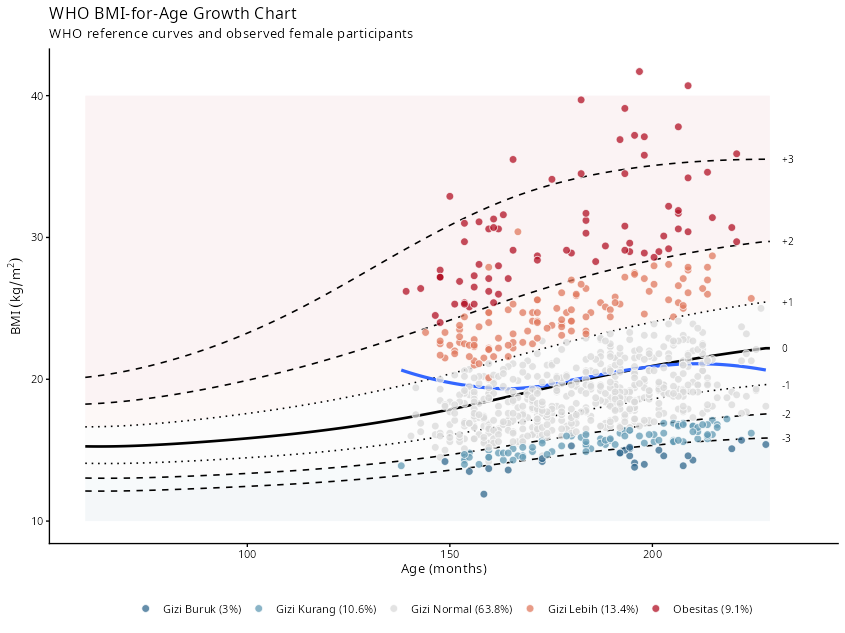

In [19]:
print(main_plot_zone)

`geom_smooth()` using formula = 'y ~ x'


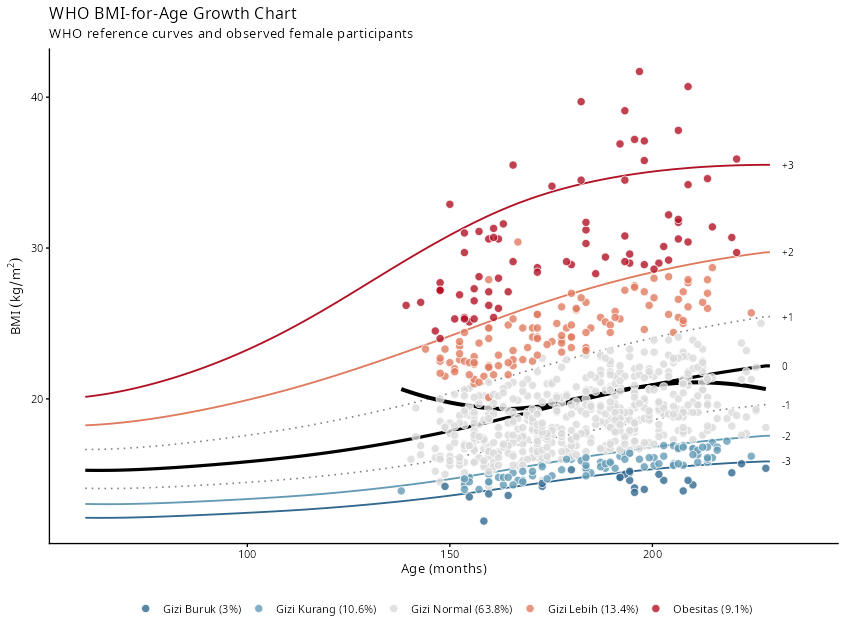

In [20]:

print(main_plot_clean)

In [21]:
# Generate the formal summary table for your manuscript
table_1 <- male_data_final %>%
  filter(!is.na(bmi_category_who)) %>%
  count(bmi_category_who) %>%
  mutate(
    Percentage = round((n / sum(n)) * 100, 1),
    # Format exactly as Q1 journals request: "n (%)"
    `n (%)` = paste0(n, " (", Percentage, "%)")
  )

# Print to console
print(table_1)

# A tibble: 5 × 4
  bmi_category_who     n Percentage `n (%)`    
  <fct>            <int>      <dbl> <chr>      
1 Gizi Buruk          25        3   25 (3%)    
2 Gizi Kurang         87       10.6 87 (10.6%) 
3 Gizi Normal        524       63.8 524 (63.8%)
4 Gizi Lebih         110       13.4 110 (13.4%)
5 Obesitas            75        9.1 75 (9.1%)  


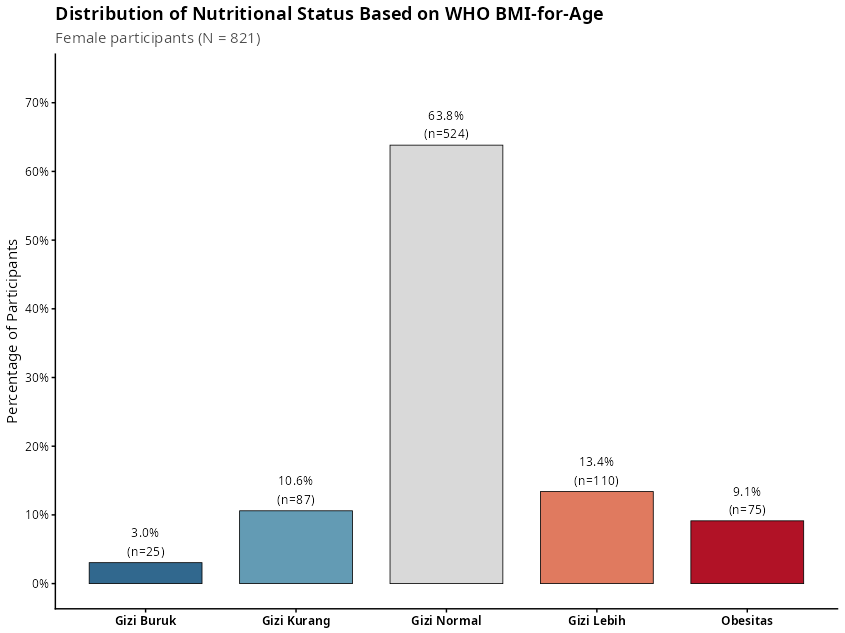

In [22]:
# DATA

cat_pct <- plot_df %>%
  count(bmi_category_who) %>%
  mutate(
    pct = 100 * n / sum(n)
  ) %>%
  mutate(
    bmi_category_who = factor(
      bmi_category_who,
      levels = c(
        "Gizi Buruk",
        "Gizi Kurang",
        "Gizi Normal",
        "Gizi Lebih",
        "Obesitas"
      )
    )
  )

N <- sum(cat_pct$n)


# PLOT
ggplot(
  cat_pct,
  aes(
    x = bmi_category_who,
    y = pct,
    fill = bmi_category_who
  )
) +

  geom_col(
    width = 0.75,
    color = "black",
    linewidth = 0.3
  ) +

  geom_text(
    aes(
      label = sprintf(
        "%.1f%%\n(n=%d)",
        pct,
        n
      )
    ),
    vjust = -0.25,
    size = 3.6
  ) +

  scale_fill_manual(
    values = c(
      "Gizi Buruk"  = "#31688e",
      "Gizi Kurang" = "#639bb4",
      "Gizi Normal" = "#d9d9d9",
      "Gizi Lebih"  = "#e07a5f",
      "Obesitas"    = "#b11226"
    )
  ) +

  scale_y_continuous(
    limits = c(
      0,
      max(cat_pct$pct) * 1.15
    ),
    breaks = pretty_breaks(6),
    labels = function(x) paste0(x, "%")
  ) +

  labs(
    title = "Distribution of Nutritional Status Based on WHO BMI-for-Age",
    subtitle = paste0("Female participants (N = ", N, ")"),
    x = NULL,
    y = "Percentage of Participants"
  ) +

  theme_classic(base_size = 12) +

  theme(
    legend.position = "none",

    plot.title = element_text(
      face = "bold"
    ),

    plot.subtitle = element_text(
      color = "grey30"
    ),

    axis.text.x = element_text(
      face = "bold"
    )
  )

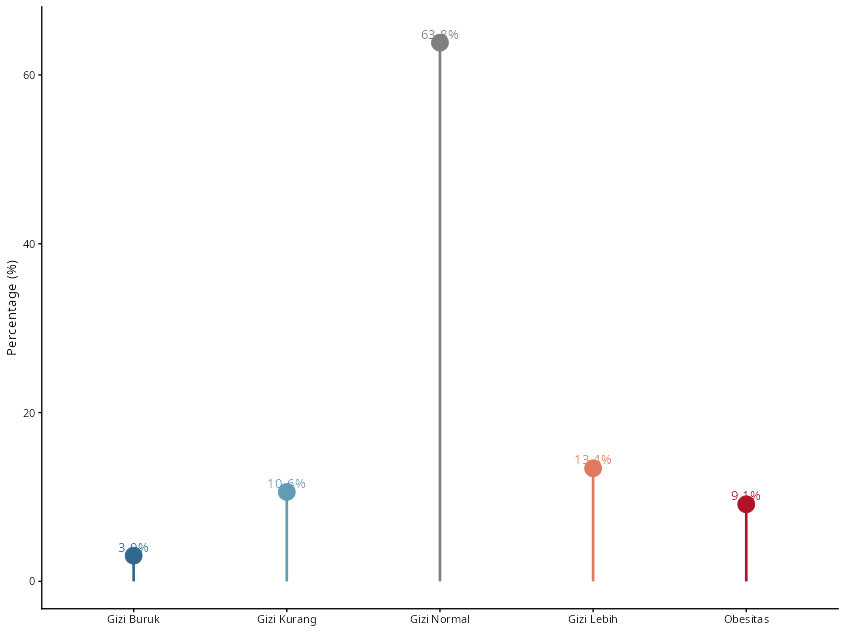

In [23]:
ggplot(
  cat_pct,
  aes(
    bmi_category_who,
    pct,
    color = bmi_category_who
  )
) +

  geom_segment(
    aes(
      xend = bmi_category_who,
      y = 0,
      yend = pct
    ),
    linewidth = 1
  ) +

  geom_point(
    size = 6
  ) +

  geom_text(
    aes(
      label = sprintf(
        "%.1f%%",
        pct
      )
    ),
    nudge_y = 1
  ) +

  scale_color_manual(
    values = c(
      "Gizi Buruk"  = "#31688e",
      "Gizi Kurang" = "#639bb4",
      "Gizi Normal" = "#7f7f7f",
      "Gizi Lebih"  = "#e07a5f",
      "Obesitas"    = "#b11226"
    )
  ) +

  theme_classic() +

  theme(
    legend.position = "none"
  ) +

  labs(
    x = NULL,
    y = "Percentage (%)"
  )

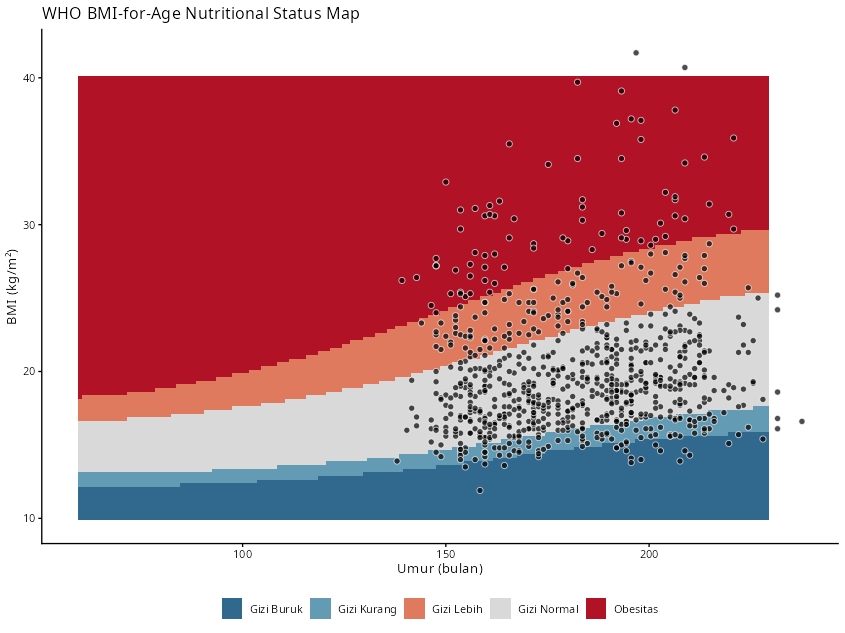

In [25]:
who_zscore <- function(bmi, l, m, s) {

  ifelse(
    l == 0,
    log(bmi / m) / s,
    (((bmi / m)^l) - 1) / (l * s)
  )

}

library(dplyr)
library(tidyr)

age_seq <- seq(
  min(who_lms$age),
  max(who_lms$age),
  by = 1
)

bmi_seq <- seq(
  10,
  40,
  by = 0.25
)

heatmap_grid <- expand.grid(
  age = age_seq,
  bmi = bmi_seq
)

heatmap_grid <- heatmap_grid %>%
  left_join(
    who_lms,
    by = "age"
  )

heatmap_grid <- heatmap_grid %>%
  mutate(
    z = who_zscore(
      bmi,
      l,
      m,
      s
    )
  )

heatmap_grid <- heatmap_grid %>%
  mutate(
    status = case_when(

      z < -3 ~ "Gizi Buruk",

      z >= -3 &
      z < -2 ~ "Gizi Kurang",

      z >= -2 &
      z <= 1 ~ "Gizi Normal",

      z > 1 &
      z <= 2 ~ "Gizi Lebih",

      z > 2 ~ "Obesitas"

    )
  )

library(ggplot2)

ggplot() +

  geom_tile(
    data = heatmap_grid,
    aes(
      age,
      bmi,
      fill = status
    )
  ) +

  geom_point(
    data = male_data_final,
    aes(
      umur_bulan,
      bmi
    ),
    shape = 21,
    size = 2,
    fill = "black",
    color = "white",
    alpha = 0.7
  ) +

  scale_fill_manual(
    values = c(

      "Gizi Buruk" =
        "#31688e",

      "Gizi Kurang" =
        "#639bb4",

      "Gizi Normal" =
        "#d9d9d9",

      "Gizi Lebih" =
        "#e07a5f",

      "Obesitas" =
        "#b11226"

    )
  ) +

  theme_classic() +

  theme(
    legend.position = "bottom",
    legend.title = element_blank()
  ) +

  labs(
    x = "Umur (bulan)",
    y = "BMI (kg/m²)",
    title =
      "WHO BMI-for-Age Nutritional Status Map"
  )